<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/GVH_TriLevel_Coupling_Test_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GVH Tri-Level Coupling Test 0.1

Objectif : tester une forme hiérarchique tri-niveau où le niveau central reçoit une contribution du niveau inférieur et du niveau supérieur.

Forme candidate :

\[
X_M(t)
=
X_M^0(t)
+
\lambda_-(t)X_L(t)
+
\lambda_+(t)X_U(t)
\]

avec :

- \(X_L(t)\) : niveau inférieur ;
- \(X_M^0(t)\) : niveau central seul ;
- \(X_U(t)\) : niveau supérieur ;
- \(\lambda_-(t)\) : couplage inférieur vers central ;
- \(\lambda_+(t)\) : couplage supérieur vers central.

Cas d’ablation :

\[
X_0=X_M^0
\]

\[
X_L^{\rm coup}=X_M^0+\lambda_-X_L
\]

\[
X_U^{\rm coup}=X_M^0+\lambda_+X_U
\]

\[
X_{LU}^{\rm coup}=X_M^0+\lambda_-X_L+\lambda_+X_U
\]

Ce test est exploratoire et séparé du notebook précédent, dont le résultat confirmatoire fort était négatif.

In [2]:
# ============================================================
# 1. Cas synthétique tri-niveau
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Grille temporelle
# ------------------------------------------------------------

N = 5000
t_min = 0.0
t_max = 40.0 * np.pi

t = np.linspace(t_min, t_max, N)


# ------------------------------------------------------------
# Niveau inférieur X_L(t)
# Mouvement rapide local
# ------------------------------------------------------------

omega_L = 1.0

X_L = np.column_stack([
    np.cos(omega_L * t),
    np.sin(omega_L * t)
])


# ------------------------------------------------------------
# Niveau central seul X_M0(t)
# Mouvement principal observé
# ------------------------------------------------------------

omega_M = 0.20

X_M0 = np.column_stack([
    np.cos(omega_M * t),
    np.sin(omega_M * t)
])


# ------------------------------------------------------------
# Niveau supérieur X_U(t)
# Mouvement lent global
# ------------------------------------------------------------

omega_U = 0.03

X_U = np.column_stack([
    np.cos(omega_U * t),
    np.sin(omega_U * t)
])


# ------------------------------------------------------------
# Couplages temporels
# ------------------------------------------------------------

lambda_minus_amp = 0.08
lambda_plus_amp  = 0.15

Omega_minus = 0.05
Omega_plus  = 0.01

lambda_minus = lambda_minus_amp * (1.0 + 0.5 * np.sin(Omega_minus * t))
lambda_plus  = lambda_plus_amp  * (1.0 + 0.5 * np.cos(Omega_plus * t))


# ------------------------------------------------------------
# Cas d'ablation
# ------------------------------------------------------------

X_0 = X_M0

X_L_coup = X_M0 + lambda_minus[:, None] * X_L

X_U_coup = X_M0 + lambda_plus[:, None] * X_U

X_LU_coup = (
    X_M0
    + lambda_minus[:, None] * X_L
    + lambda_plus[:, None] * X_U
)


# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

print("Cas synthétique tri-niveau défini :")
print(f"t          : {t.shape}")
print(f"X_L        : {X_L.shape}")
print(f"X_M0       : {X_M0.shape}")
print(f"X_U        : {X_U.shape}")
print(f"lambda_-   : {lambda_minus.shape}")
print(f"lambda_+   : {lambda_plus.shape}")
print(f"X_0        : {X_0.shape}")
print(f"X_L_coup   : {X_L_coup.shape}")
print(f"X_U_coup   : {X_U_coup.shape}")
print(f"X_LU_coup  : {X_LU_coup.shape}")

print("\nPlages des couplages :")
print(f"lambda_- min/max = {lambda_minus.min():.6f} / {lambda_minus.max():.6f}")
print(f"lambda_+ min/max = {lambda_plus.min():.6f} / {lambda_plus.max():.6f}")

Cas synthétique tri-niveau défini :
t          : (5000,)
X_L        : (5000, 2)
X_M0       : (5000, 2)
X_U        : (5000, 2)
lambda_-   : (5000,)
lambda_+   : (5000,)
X_0        : (5000, 2)
X_L_coup   : (5000, 2)
X_U_coup   : (5000, 2)
X_LU_coup  : (5000, 2)

Plages des couplages :
lambda_- min/max = 0.040000 / 0.120000
lambda_+ min/max = 0.173176 / 0.225000


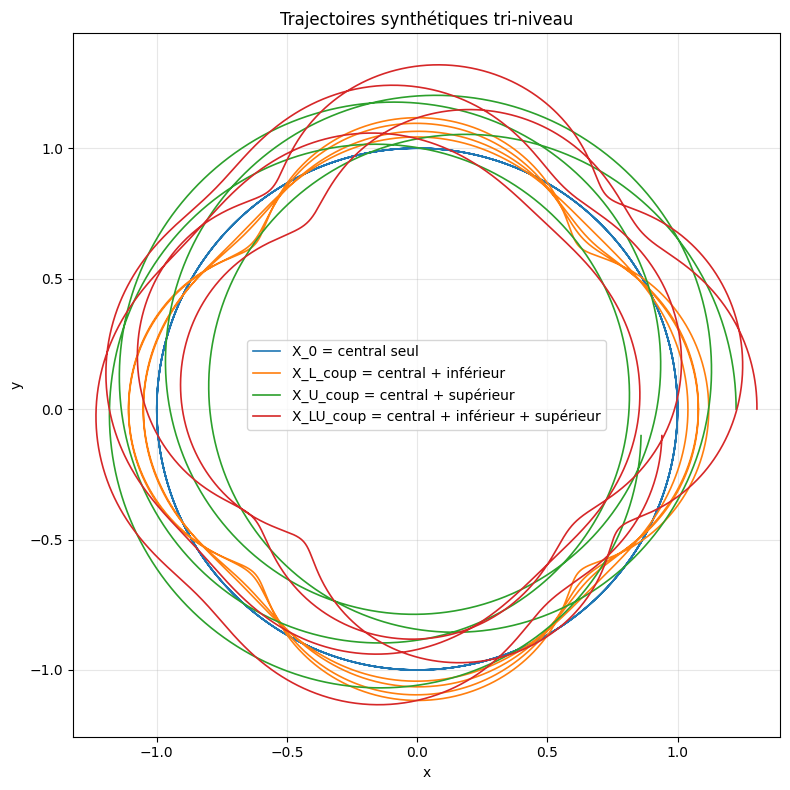

In [3]:
# ============================================================
# 2. Visualisation des trajectoires tri-niveau
# ============================================================

cases = {
    "X_0 = central seul": X_0,
    "X_L_coup = central + inférieur": X_L_coup,
    "X_U_coup = central + supérieur": X_U_coup,
    "X_LU_coup = central + inférieur + supérieur": X_LU_coup,
}

plt.figure(figsize=(8, 8))

for name, X_case in cases.items():
    plt.plot(X_case[:, 0], X_case[:, 1], linewidth=1.2, label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectoires synthétiques tri-niveau")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 3. Observables géométriques brutes D_T et S_T
# Aucune normalisation par D_max
# ============================================================

def compute_D_T(X):
    X = np.asarray(X, dtype=float)
    return np.linalg.norm(
        np.diff(X, axis=0),
        axis=1
    )


def compute_S_T(D):
    D = np.asarray(D, dtype=float)
    return np.abs(np.diff(D))


# ------------------------------------------------------------
# Calcul pour les quatre cas
# ------------------------------------------------------------

D_tri = {
    "X_0":       compute_D_T(X_0),
    "X_L_coup":  compute_D_T(X_L_coup),
    "X_U_coup":  compute_D_T(X_U_coup),
    "X_LU_coup": compute_D_T(X_LU_coup),
}

S_tri = {
    name: compute_S_T(D)
    for name, D in D_tri.items()
}


# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

print("Observables tri-niveau brutes")
print("=" * 92)

print(
    "Cas        | N_D  | D_mean       | D_std        | "
    "D_min        | D_max        | S_mean"
)

print("-" * 92)

for name in D_tri:

    D = D_tri[name]
    S = S_tri[name]

    print(
        f"{name:10s} | "
        f"{len(D):4d} | "
        f"{np.mean(D):.12f} | "
        f"{np.std(D):.12f} | "
        f"{np.min(D):.12f} | "
        f"{np.max(D):.12f} | "
        f"{np.mean(S):.12e}"
    )

Observables tri-niveau brutes
Cas        | N_D  | D_mean       | D_std        | D_min        | D_max        | S_mean
--------------------------------------------------------------------------------------------
X_0        | 4999 | 0.005027548462 | 0.000000000000 | 0.005027548462 | 0.005027548462 | 1.422456069666e-15
X_L_coup   | 4999 | 0.005257704637 | 0.001477681543 | 0.002030425577 | 0.008043977168 | 2.577160119760e-05
X_U_coup   | 4999 | 0.005033197492 | 0.000109820863 | 0.004858807358 | 0.005197228026 | 4.281843775603e-07
X_LU_coup  | 4999 | 0.005263766424 | 0.001480431963 | 0.002014150470 | 0.008140201563 | 2.576544725953e-05


In [5]:
# ============================================================
# 4. Écarts directs entre cas tri-niveau
# ============================================================

D_0  = D_tri["X_0"]
D_L  = D_tri["X_L_coup"]
D_U  = D_tri["X_U_coup"]
D_LU = D_tri["X_LU_coup"]

diff_LU_L = D_LU - D_L
diff_LU_U = D_LU - D_U
diff_LU_0 = D_LU - D_0

print("Écarts directs sur D_T")
print("=" * 80)

def summarize_diff(name, diff):
    print(f"{name}")
    print(f"  mean = {np.mean(diff): .12e}")
    print(f"  std  = {np.std(diff): .12e}")
    print(f"  min  = {np.min(diff): .12e}")
    print(f"  max  = {np.max(diff): .12e}")
    print(f"  abs_mean = {np.mean(np.abs(diff)): .12e}")
    print()

summarize_diff("D_LU - D_L", diff_LU_L)
summarize_diff("D_LU - D_U", diff_LU_U)
summarize_diff("D_LU - D_0", diff_LU_0)

# Rapport de taille : ajout supérieur par rapport au signal inférieur
ratio_abs = np.mean(np.abs(diff_LU_L)) / np.mean(np.abs(D_L - D_0))

print("Ratio relatif :")
print(f"mean|D_LU-D_L| / mean|D_L-D_0| = {ratio_abs:.12f}")

Écarts directs sur D_T
D_LU - D_L
  mean =  6.061787744487e-06
  std  =  1.096699343228e-04
  min  = -1.689108491298e-04
  max  =  1.696795532562e-04
  abs_mean =  9.828127929074e-05

D_LU - D_U
  mean =  2.305689328845e-04
  std  =  1.477747114703e-03
  min  = -2.997596492880e-03
  max  =  3.016384153445e-03
  abs_mean =  1.267959277919e-03

D_LU - D_0
  mean =  2.362179628770e-04
  std  =  1.480431962725e-03
  min  = -3.013397991176e-03
  max  =  3.112653101842e-03
  abs_mean =  1.270091969648e-03

Ratio relatif :
mean|D_LU-D_L| / mean|D_L-D_0| = 0.077519180169


Résidu de non-additivité géométrique I_D
mean     =  4.127577520066e-07
std      =  3.573679217786e-05
min      = -1.037410784039e-04
max      =  1.050629725452e-04
abs_mean =  2.681764551900e-05
rms      =  3.573917576169e-05

Ratios relatifs :
mean|I_D| / mean|D_L-D_0| = 0.021152369095
mean|I_D| / mean|D_U-D_0| = 0.272834899156


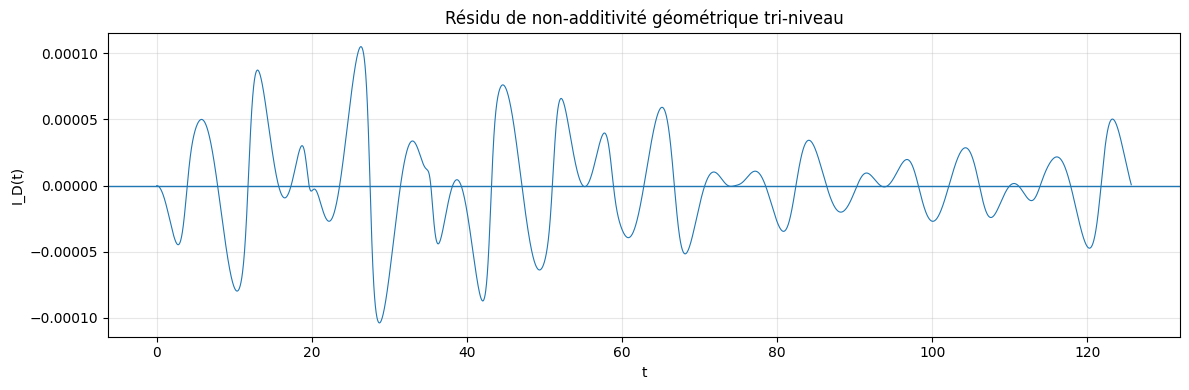

In [6]:
# ============================================================
# 5. Résidu de non-additivité géométrique
# ============================================================

I_D = D_LU - D_L - D_U + D_0

print("Résidu de non-additivité géométrique I_D")
print("=" * 72)

print(f"mean     = {np.mean(I_D): .12e}")
print(f"std      = {np.std(I_D): .12e}")
print(f"min      = {np.min(I_D): .12e}")
print(f"max      = {np.max(I_D): .12e}")
print(f"abs_mean = {np.mean(np.abs(I_D)): .12e}")
print(f"rms      = {np.sqrt(np.mean(I_D**2)): .12e}")

# ------------------------------------------------------------
# Échelles de référence
# ------------------------------------------------------------

effect_L = D_L - D_0
effect_U = D_U - D_0

ratio_to_L = (
    np.mean(np.abs(I_D))
    / np.mean(np.abs(effect_L))
)

ratio_to_U = (
    np.mean(np.abs(I_D))
    / np.mean(np.abs(effect_U))
)

print("\nRatios relatifs :")
print(
    "mean|I_D| / mean|D_L-D_0| = "
    f"{ratio_to_L:.12f}"
)
print(
    "mean|I_D| / mean|D_U-D_0| = "
    f"{ratio_to_U:.12f}"
)

# ------------------------------------------------------------
# Structure temporelle
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(t[1:], I_D, linewidth=0.8)
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("t")
plt.ylabel("I_D(t)")
plt.title("Résidu de non-additivité géométrique tri-niveau")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 6. Null circulaire sur les couplages lambda_- et lambda_+
# ============================================================

N_surr = 1000
seed_surr = 20260708
rng = np.random.default_rng(seed_surr)

I_obs_abs_mean = np.mean(np.abs(I_D))
I_obs_rms = np.sqrt(np.mean(I_D**2))

null_minus_abs = np.empty(N_surr)
null_minus_rms = np.empty(N_surr)

null_plus_abs = np.empty(N_surr)
null_plus_rms = np.empty(N_surr)

for s in range(N_surr):

    # --------------------------------------------------------
    # Null 1 : décaler lambda_-
    # --------------------------------------------------------
    shift_minus = rng.integers(1, N)

    lambda_minus_shift = np.roll(lambda_minus, shift_minus)

    X_L_shift = X_M0 + lambda_minus_shift[:, None] * X_L
    X_LU_shift_minus = (
        X_M0
        + lambda_minus_shift[:, None] * X_L
        + lambda_plus[:, None] * X_U
    )

    D_L_shift = compute_D_T(X_L_shift)
    D_LU_shift_minus = compute_D_T(X_LU_shift_minus)

    I_minus = D_LU_shift_minus - D_L_shift - D_U + D_0

    null_minus_abs[s] = np.mean(np.abs(I_minus))
    null_minus_rms[s] = np.sqrt(np.mean(I_minus**2))


    # --------------------------------------------------------
    # Null 2 : décaler lambda_+
    # --------------------------------------------------------
    shift_plus = rng.integers(1, N)

    lambda_plus_shift = np.roll(lambda_plus, shift_plus)

    X_U_shift = X_M0 + lambda_plus_shift[:, None] * X_U
    X_LU_shift_plus = (
        X_M0
        + lambda_minus[:, None] * X_L
        + lambda_plus_shift[:, None] * X_U
    )

    D_U_shift = compute_D_T(X_U_shift)
    D_LU_shift_plus = compute_D_T(X_LU_shift_plus)

    I_plus = D_LU_shift_plus - D_L - D_U_shift + D_0

    null_plus_abs[s] = np.mean(np.abs(I_plus))
    null_plus_rms[s] = np.sqrt(np.mean(I_plus**2))


# ============================================================
# Résumé
# ============================================================

def summarize_null(label, null_values, obs_value):
    percentile = np.mean(null_values <= obs_value)
    p_upper = (1 + np.sum(null_values >= obs_value)) / (len(null_values) + 1)

    print(label)
    print("-" * 72)
    print(f"obs        = {obs_value:.12e}")
    print(f"mean null  = {np.mean(null_values):.12e}")
    print(f"median     = {np.median(null_values):.12e}")
    print(f"std        = {np.std(null_values, ddof=1):.12e}")
    print(f"Q2.5       = {np.percentile(null_values, 2.5):.12e}")
    print(f"Q97.5      = {np.percentile(null_values, 97.5):.12e}")
    print(f"percentile = {percentile:.6f}")
    print(f"p_upper    = {p_upper:.6f}")
    print()

print("Null circulaire sur les couplages")
print("=" * 72)

summarize_null(
    "Null lambda_- décalé — métrique mean|I_D|",
    null_minus_abs,
    I_obs_abs_mean
)

summarize_null(
    "Null lambda_+ décalé — métrique mean|I_D|",
    null_plus_abs,
    I_obs_abs_mean
)

summarize_null(
    "Null lambda_- décalé — métrique RMS(I_D)",
    null_minus_rms,
    I_obs_rms
)

summarize_null(
    "Null lambda_+ décalé — métrique RMS(I_D)",
    null_plus_rms,
    I_obs_rms
)

Null circulaire sur les couplages
Null lambda_- décalé — métrique mean|I_D|
------------------------------------------------------------------------
obs        = 2.681764551900e-05
mean null  = 2.636037769845e-05
median     = 2.640732943818e-05
std        = 3.510783757390e-07
Q2.5       = 2.581932313824e-05
Q97.5      = 2.682768613194e-05
percentile = 0.928000
p_upper    = 0.072927

Null lambda_+ décalé — métrique mean|I_D|
------------------------------------------------------------------------
obs        = 2.681764551900e-05
mean null  = 2.660141368247e-05
median     = 2.662283034875e-05
std        = 5.092373306287e-07
Q2.5       = 2.570860830643e-05
Q97.5      = 2.749301286943e-05
percentile = 0.678000
p_upper    = 0.322677

Null lambda_- décalé — métrique RMS(I_D)
------------------------------------------------------------------------
obs        = 3.573917576169e-05
mean null  = 3.456149376651e-05
median     = 3.471935765300e-05
std        = 9.171064367670e-07
Q2.5       = 3.31783

In [8]:
# ============================================================
# 7. Null circulaire conjoint : lambda_- et lambda_+ décalés
# indépendamment dans chaque surrogate
# ============================================================

N_surr_joint = 1000
seed_joint = 20260708 + 1
rng_joint = np.random.default_rng(seed_joint)

joint_abs = np.empty(N_surr_joint)
joint_rms = np.empty(N_surr_joint)

for s in range(N_surr_joint):

    shift_minus = rng_joint.integers(1, N)
    shift_plus  = rng_joint.integers(1, N)

    lambda_minus_shift = np.roll(lambda_minus, shift_minus)
    lambda_plus_shift  = np.roll(lambda_plus, shift_plus)

    X_L_shift = X_M0 + lambda_minus_shift[:, None] * X_L
    X_U_shift = X_M0 + lambda_plus_shift[:, None] * X_U

    X_LU_shift_joint = (
        X_M0
        + lambda_minus_shift[:, None] * X_L
        + lambda_plus_shift[:, None] * X_U
    )

    D_L_shift = compute_D_T(X_L_shift)
    D_U_shift = compute_D_T(X_U_shift)
    D_LU_shift_joint = compute_D_T(X_LU_shift_joint)

    I_joint = (
        D_LU_shift_joint
        - D_L_shift
        - D_U_shift
        + D_0
    )

    joint_abs[s] = np.mean(np.abs(I_joint))
    joint_rms[s] = np.sqrt(np.mean(I_joint**2))


print("Null circulaire conjoint lambda_- / lambda_+")
print("=" * 72)

summarize_null(
    "Null conjoint — métrique mean|I_D|",
    joint_abs,
    I_obs_abs_mean
)

summarize_null(
    "Null conjoint — métrique RMS(I_D)",
    joint_rms,
    I_obs_rms
)

Null circulaire conjoint lambda_- / lambda_+
Null conjoint — métrique mean|I_D|
------------------------------------------------------------------------
obs        = 2.681764551900e-05
mean null  = 2.666622928369e-05
median     = 2.664115773649e-05
std        = 5.284034870646e-07
Q2.5       = 2.570930245554e-05
Q97.5      = 2.772284217996e-05
percentile = 0.597000
p_upper    = 0.403596

Null conjoint — métrique RMS(I_D)
------------------------------------------------------------------------
obs        = 3.573917576169e-05
mean null  = 4.502877159757e-05
median     = 4.020584352167e-05
std        = 1.246798974346e-05
Q2.5       = 3.361858800778e-05
Q97.5      = 7.963142604199e-05
percentile = 0.235000
p_upper    = 0.765235



## Principe méthodologique — Non-additivité induite par l’observable

Considérons une trajectoire additive :

\[
X(t)
=
X_0(t)
+
X_1(t)
+
X_2(t).
\]

L’additivité de \(X\) n’implique pas l’additivité de l’observable :

\[
D_T[X]
=
\|\Delta X\|.
\]

En effet :

\[
D_T[X_0+X_1+X_2]
=
\|\Delta X_0+\Delta X_1+\Delta X_2\|,
\]

et, en général,

\[
\|\Delta X_0+\Delta X_1+\Delta X_2\|
\neq
\|\Delta X_0\|
+
\|\Delta X_1\|
+
\|\Delta X_2\|.
\]

Par conséquent, un résidu de type :

\[
I_D
=
D_T[X_{012}]
-
D_T[X_{01}]
-
D_T[X_{02}]
+
D_T[X_0]
\]

peut être non nul même lorsque le modèle générateur est strictement additif et ne contient aucun terme d’interaction dynamique entre niveaux.

Ainsi :

\[
\boxed{
I_D\neq0
\;\not\Rightarrow\;
\text{interaction dynamique}
}
\]

La non-additivité d’une observable dérivée ne doit pas être confondue avec la non-additivité du système générateur.

### Conséquence pour le protocole GVH

Toute revendication d’interaction entre niveaux doit désormais satisfaire au minimum les conditions suivantes :

1. le modèle générateur candidat contient un terme d’interaction explicite ;
2. l’ablation de ce terme est définie au niveau des équations génératrices ;
3. le null casse spécifiquement l’interaction tout en préservant autant que possible les propriétés marginales des niveaux ;
4. les observables GVH sont comparées entre modèle interactif, ablation sans interaction et null adapté ;
5. une non-additivité observée uniquement après application de \(D_T\), \(S_T\), \(R_D\), \(R_{\rm super}\) ou d’une autre transformation non linéaire ne constitue pas, à elle seule, une preuve d’interaction physique.

Ce principe est adopté à la suite du test tri-niveau additif, où une non-additivité descriptive de \(D_T\) a été observée mais n’a pas dépassé le null circulaire conjoint.